<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Batch%20Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Batch Normalization

Ebben a notebookban a **Batch Normalization** és más normalizációs technikákat vizsgáljuk.

## Tartalomjegyzék

1. Internal Covariate Shift
2. Batch Normalization működése
3. Training vs Inference
4. Normalizációs variánsok
5. PyTorch implementáció

## 1. Internal Covariate Shift

### A probléma

| Jelenség | Leírás |
|----------|--------|
| Covariate shift | Input eloszlás változik |
| Internal | Rejtett rétegek közötti változás |
| Hatás | Tanulás lassul, instabil |

### Megoldás

Aktivációk normalizálása minden mini-batch-en.

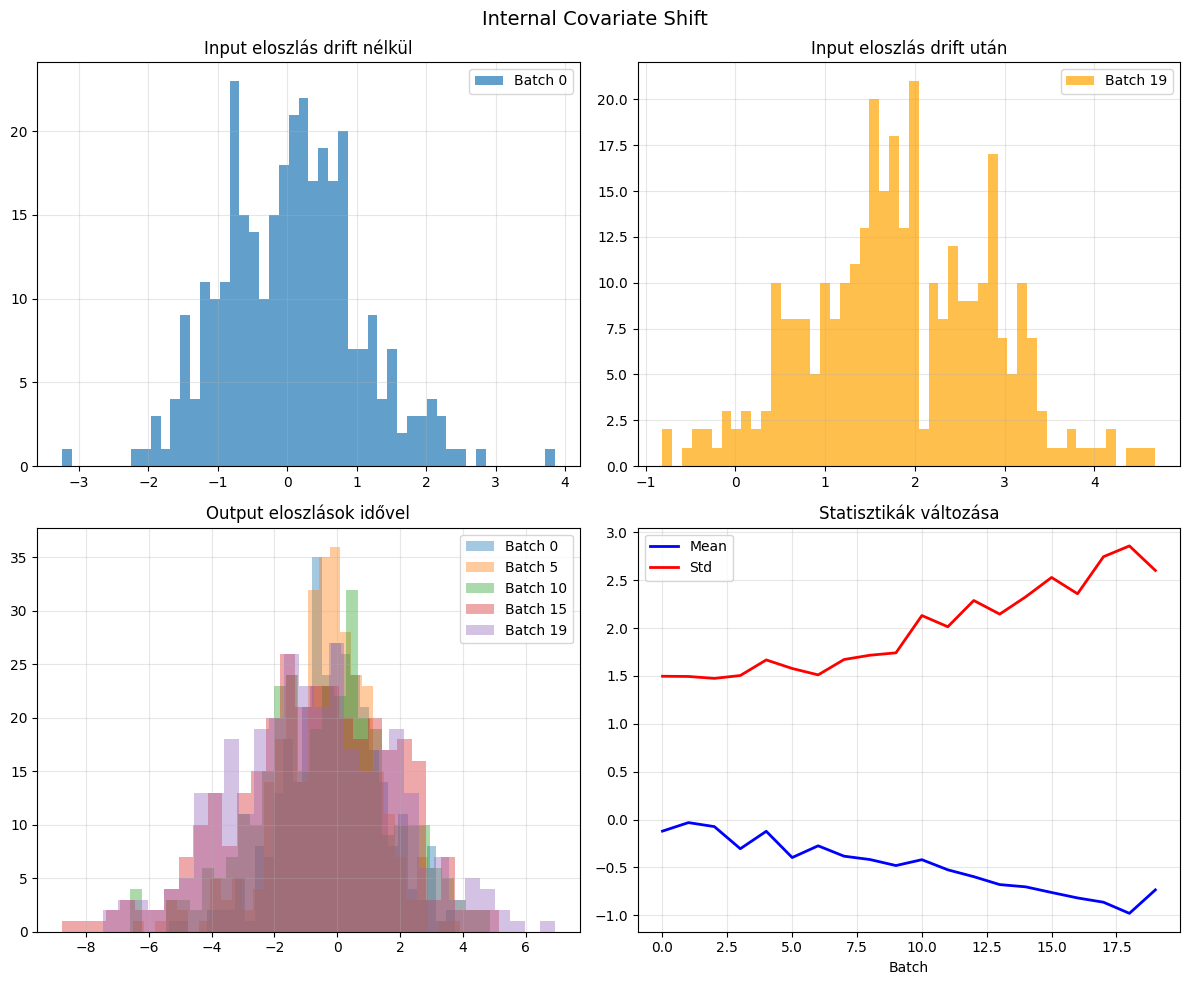

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

# Internal covariate shift demonstráció
def simulate_covariate_shift(n_batches=20):
    """Szimulál covariate shift-et."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Lineáris réteg szimulálása
    W = np.random.randn(10, 10) * 0.5

    # Batch-ek különböző eloszlásokból
    batches_before = []
    batches_after = []

    for i in range(n_batches):
        # Drift a bemeneti eloszlásban
        mean_shift = 0.1 * i
        x = np.random.randn(32, 10) + mean_shift
        batches_before.append(x)

        # Réteg kimenete
        z = x @ W
        batches_after.append(z)

    # Vizualizáció
    axes[0, 0].set_title('Input eloszlás drift nélkül')
    axes[0, 0].hist(batches_before[0].flatten(), bins=50, alpha=0.7, label='Batch 0')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_title('Input eloszlás drift után')
    axes[0, 1].hist(batches_before[-1].flatten(), bins=50, alpha=0.7, label=f'Batch {n_batches-1}', color='orange')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Output shift
    axes[1, 0].set_title('Output eloszlások idővel')
    for i in [0, 5, 10, 15, 19]:
        axes[1, 0].hist(batches_after[i].flatten(), bins=30, alpha=0.4, label=f'Batch {i}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Mean és variance változás
    means = [b.mean() for b in batches_after]
    stds = [b.std() for b in batches_after]

    axes[1, 1].plot(means, 'b-', label='Mean', linewidth=2)
    axes[1, 1].plot(stds, 'r-', label='Std', linewidth=2)
    axes[1, 1].set_xlabel('Batch')
    axes[1, 1].set_title('Statisztikák változása')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Internal Covariate Shift', fontsize=14)
    plt.tight_layout()
    plt.show()

simulate_covariate_shift()

## 2. Batch Normalization működése

### Forward pass

1. **Mini-batch statisztikák:**
$$\mu_B = \frac{1}{m}\sum_{i=1}^{m} x_i$$
$$\sigma_B^2 = \frac{1}{m}\sum_{i=1}^{m} (x_i - \mu_B)^2$$

2. **Normalizálás:**
$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

3. **Scale and shift (tanulható):**
$$y_i = \gamma \hat{x}_i + \beta$$

### Miért $\gamma$ és $\beta$?

A hálózat visszakaphatja az eredeti eloszlást, ha szükséges.

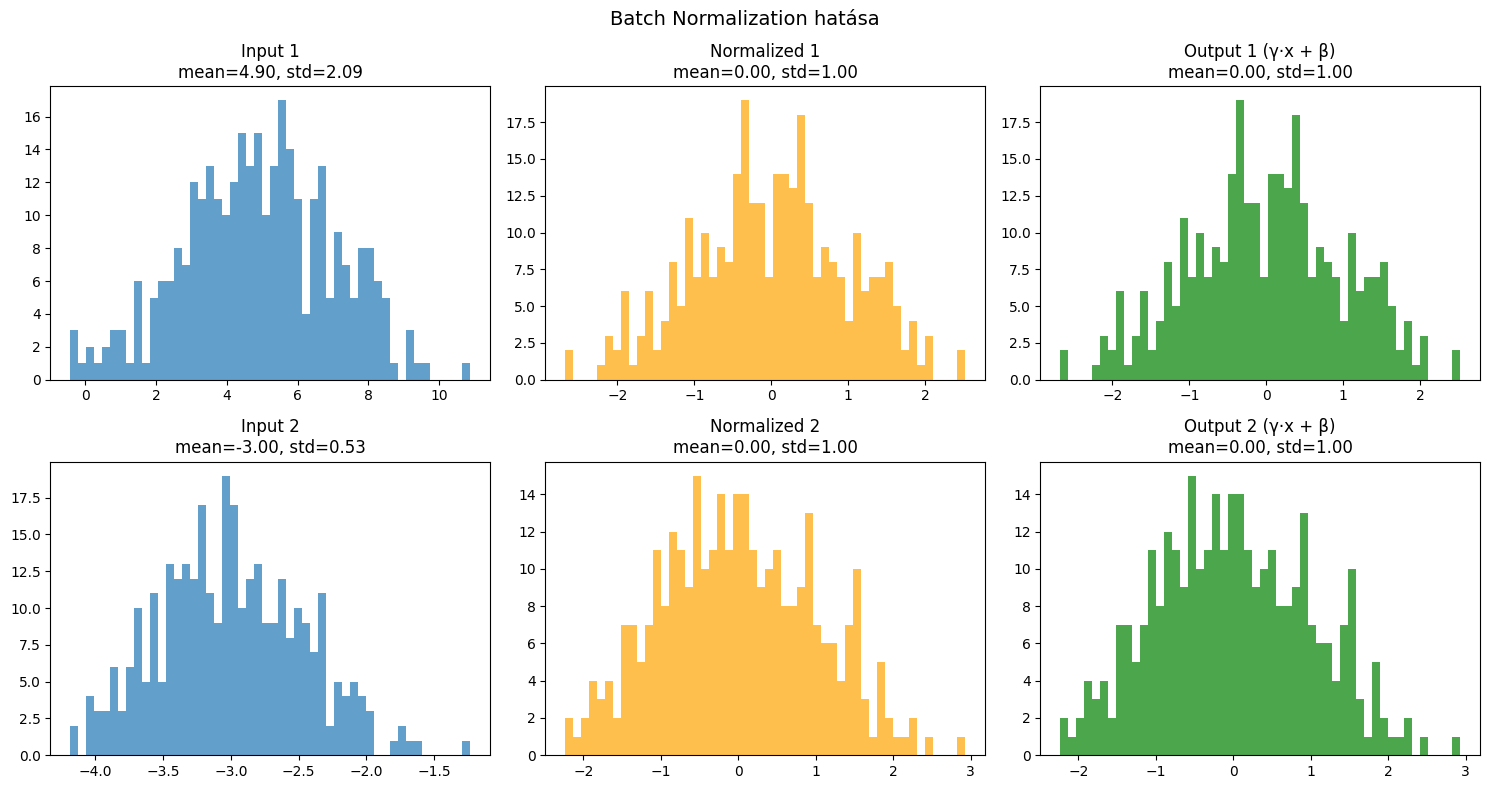

In [3]:
# Batch Normalization implementáció numpy-val

class BatchNormNumpy:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.eps = eps
        self.momentum = momentum

        # Running statistics
        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)

    def forward(self, x, training=True):
        if training:
            # Mini-batch statisztikák
            batch_mean = x.mean(axis=0)
            batch_var = x.var(axis=0)

            # Update running stats
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * batch_var

            # Normalizálás batch statisztikákkal
            x_norm = (x - batch_mean) / np.sqrt(batch_var + self.eps)
        else:
            # Inference: running stats használata
            x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)

        # Scale and shift
        out = self.gamma * x_norm + self.beta

        return out, x_norm

# Demonstráció
bn = BatchNormNumpy(10)

# Input különböző eloszlásokból
x1 = np.random.randn(32, 10) * 2 + 5  # mean=5, std=2
x2 = np.random.randn(32, 10) * 0.5 - 3  # mean=-3, std=0.5

out1, norm1 = bn.forward(x1, training=True)
out2, norm2 = bn.forward(x2, training=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Input 1
axes[0, 0].hist(x1.flatten(), bins=50, alpha=0.7)
axes[0, 0].set_title(f'Input 1\nmean={x1.mean():.2f}, std={x1.std():.2f}')

axes[0, 1].hist(norm1.flatten(), bins=50, alpha=0.7, color='orange')
axes[0, 1].set_title(f'Normalized 1\nmean={norm1.mean():.2f}, std={norm1.std():.2f}')

axes[0, 2].hist(out1.flatten(), bins=50, alpha=0.7, color='green')
axes[0, 2].set_title(f'Output 1 (γ·x + β)\nmean={out1.mean():.2f}, std={out1.std():.2f}')

# Input 2
axes[1, 0].hist(x2.flatten(), bins=50, alpha=0.7)
axes[1, 0].set_title(f'Input 2\nmean={x2.mean():.2f}, std={x2.std():.2f}')

axes[1, 1].hist(norm2.flatten(), bins=50, alpha=0.7, color='orange')
axes[1, 1].set_title(f'Normalized 2\nmean={norm2.mean():.2f}, std={norm2.std():.2f}')

axes[1, 2].hist(out2.flatten(), bins=50, alpha=0.7, color='green')
axes[1, 2].set_title(f'Output 2 (γ·x + β)\nmean={out2.mean():.2f}, std={out2.std():.2f}')

plt.suptitle('Batch Normalization hatása', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Training vs Inference

### Training
- Mini-batch statisztikák használata
- Running mean/variance frissítése

### Inference
- Running statisztikák használata (exponential moving average)
- Determinisztikus kimenet

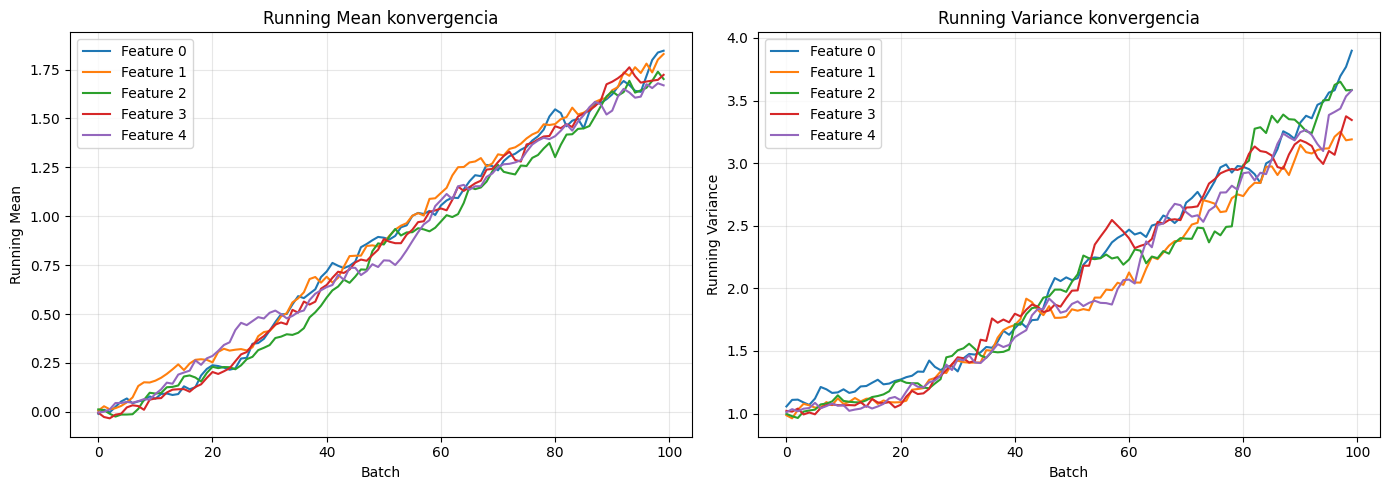

In [4]:
# Running statistics demonstráció

bn = BatchNormNumpy(5, momentum=0.1)

# Sok batch feldolgozása
running_means_history = []
running_vars_history = []

for i in range(100):
    # Random batch
    x = np.random.randn(32, 5) * (1 + 0.01*i) + 0.02*i
    bn.forward(x, training=True)

    running_means_history.append(bn.running_mean.copy())
    running_vars_history.append(bn.running_var.copy())

running_means = np.array(running_means_history)
running_vars = np.array(running_vars_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Running mean
for i in range(5):
    axes[0].plot(running_means[:, i], label=f'Feature {i}')
axes[0].set_xlabel('Batch')
axes[0].set_ylabel('Running Mean')
axes[0].set_title('Running Mean konvergencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Running var
for i in range(5):
    axes[1].plot(running_vars[:, i], label=f'Feature {i}')
axes[1].set_xlabel('Batch')
axes[1].set_ylabel('Running Variance')
axes[1].set_title('Running Variance konvergencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Training vs Inference mód

# PyTorch BatchNorm
bn_torch = nn.BatchNorm1d(10)

# Training mode
bn_torch.train()
x_train = torch.randn(32, 10) * 3 + 2

# Több batch training
for _ in range(100):
    x_train = torch.randn(32, 10) * 3 + 2
    _ = bn_torch(x_train)

print("Training után:")
print(f"Running mean: {bn_torch.running_mean[:5].detach().numpy()}")
print(f"Running var: {bn_torch.running_var[:5].detach().numpy()}")

# Evaluation mode
bn_torch.eval()

# Inference különböző batch méretekkel
print("\nInference konzisztencia:")
x_test = torch.randn(1, 10) * 3 + 2  # Egyetlen minta!
out1 = bn_torch(x_test)
out2 = bn_torch(x_test)
print(f"Azonos kimenet: {torch.allclose(out1, out2)}")

Training után:
Running mean: [2.0569959 1.9994904 2.1848218 2.235893  2.007508 ]
Running var: [8.8500805 8.648791  9.28375   8.741009  9.375331 ]

Inference konzisztencia:
Azonos kimenet: True


## 4. Normalizációs variánsok

### Összehasonlítás

| Típus | Normalizálás dimenziója | Használat |
|-------|------------------------|----------|
| BatchNorm | (N, C, *) → C mentén | CNN |
| LayerNorm | (N, *) → feature mentén | Transformer |
| InstanceNorm | (N, C, H, W) → H, W mentén | Style transfer |
| GroupNorm | (N, G, C/G, *) → group mentén | Kis batch |

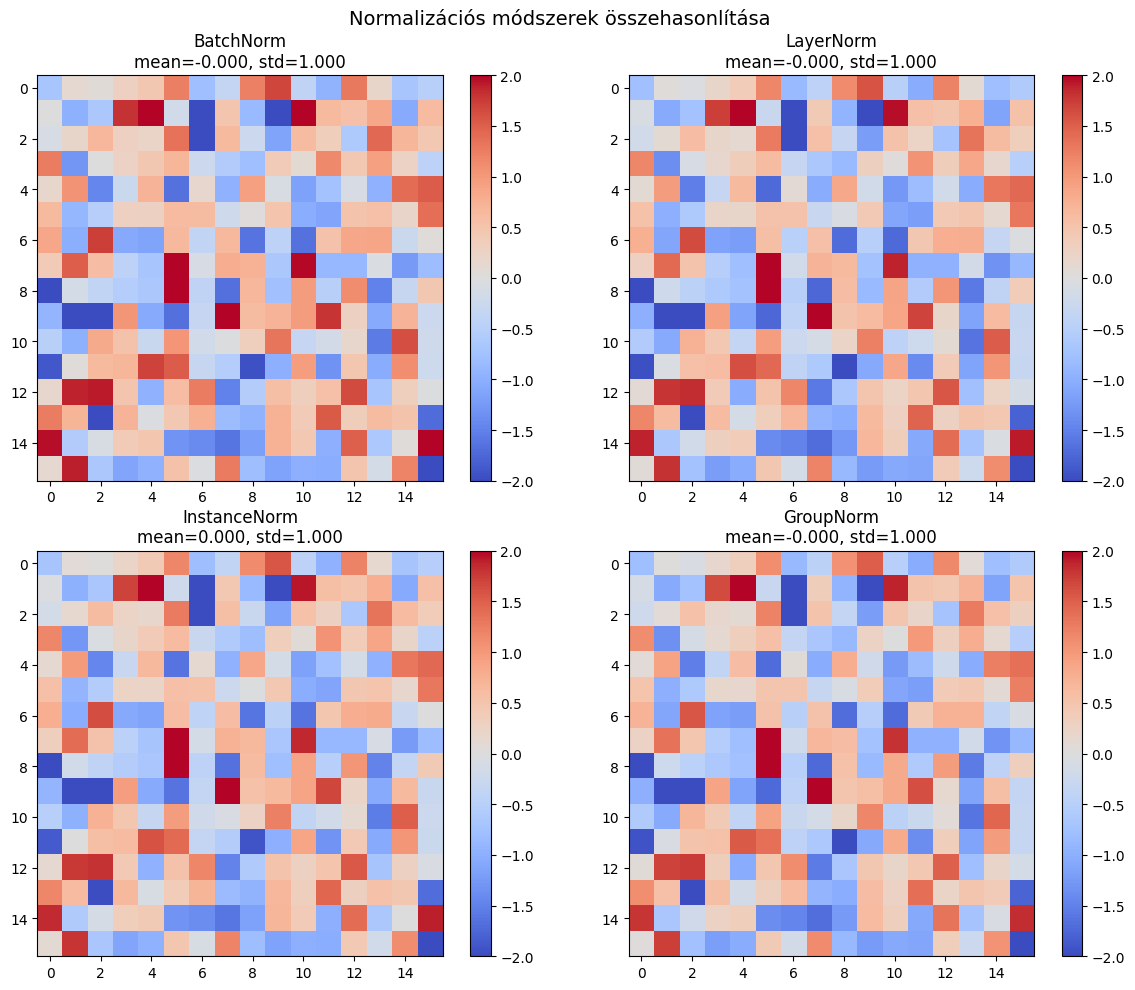

In [8]:
# Normalizációs rétegek összehasonlítása

# Képszerű adat: (batch, channels, height, width)
x = torch.randn(4, 8, 16, 16)  # 4 kép, 8 csatorna, 16x16

# Különböző normalizációk
batch_norm = nn.BatchNorm2d(8)
layer_norm = nn.LayerNorm([8, 16, 16])
instance_norm = nn.InstanceNorm2d(8)
group_norm = nn.GroupNorm(4, 8)  # 4 group, 8 channel

norms = {
    'BatchNorm': batch_norm(x),
    'LayerNorm': layer_norm(x),
    'InstanceNorm': instance_norm(x),
    'GroupNorm': group_norm(x)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, out) in zip(axes, norms.items()):
    # Első kép, első csatorna
    img = out[0, 0].detach().numpy()

    im = ax.imshow(img, cmap='coolwarm', vmin=-2, vmax=2)
    ax.set_title(f'{name}\nmean={out.mean():.3f}, std={out.std():.3f}')
    plt.colorbar(im, ax=ax)

plt.suptitle('Normalizációs módszerek összehasonlítása', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Balint\AppData\Local\Temp\ipykernel_13712\595653847.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((col*2, 0), 2, 10, alpha=0.3, color=color if col == 2 else 'white', edgecolor='black')
C:\Users\Balint\AppData\Local\Temp\ipykernel_13712\595653847.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((0, 8), 10, 2, alpha=0.3, color=color, edgecolor='black')
C:\Users\Balint\AppData\Local\Temp\ipykernel_13712\595653847.py:35: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((4, 8), 2, 2, alpha=0.3, color=color, edgecolor='black')
C:\Users\Balint\AppData\Local\Temp\ipykernel_13712\595653847.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((2, 8), 4, 2, alpha=0.3, color=color, edgecolor='black

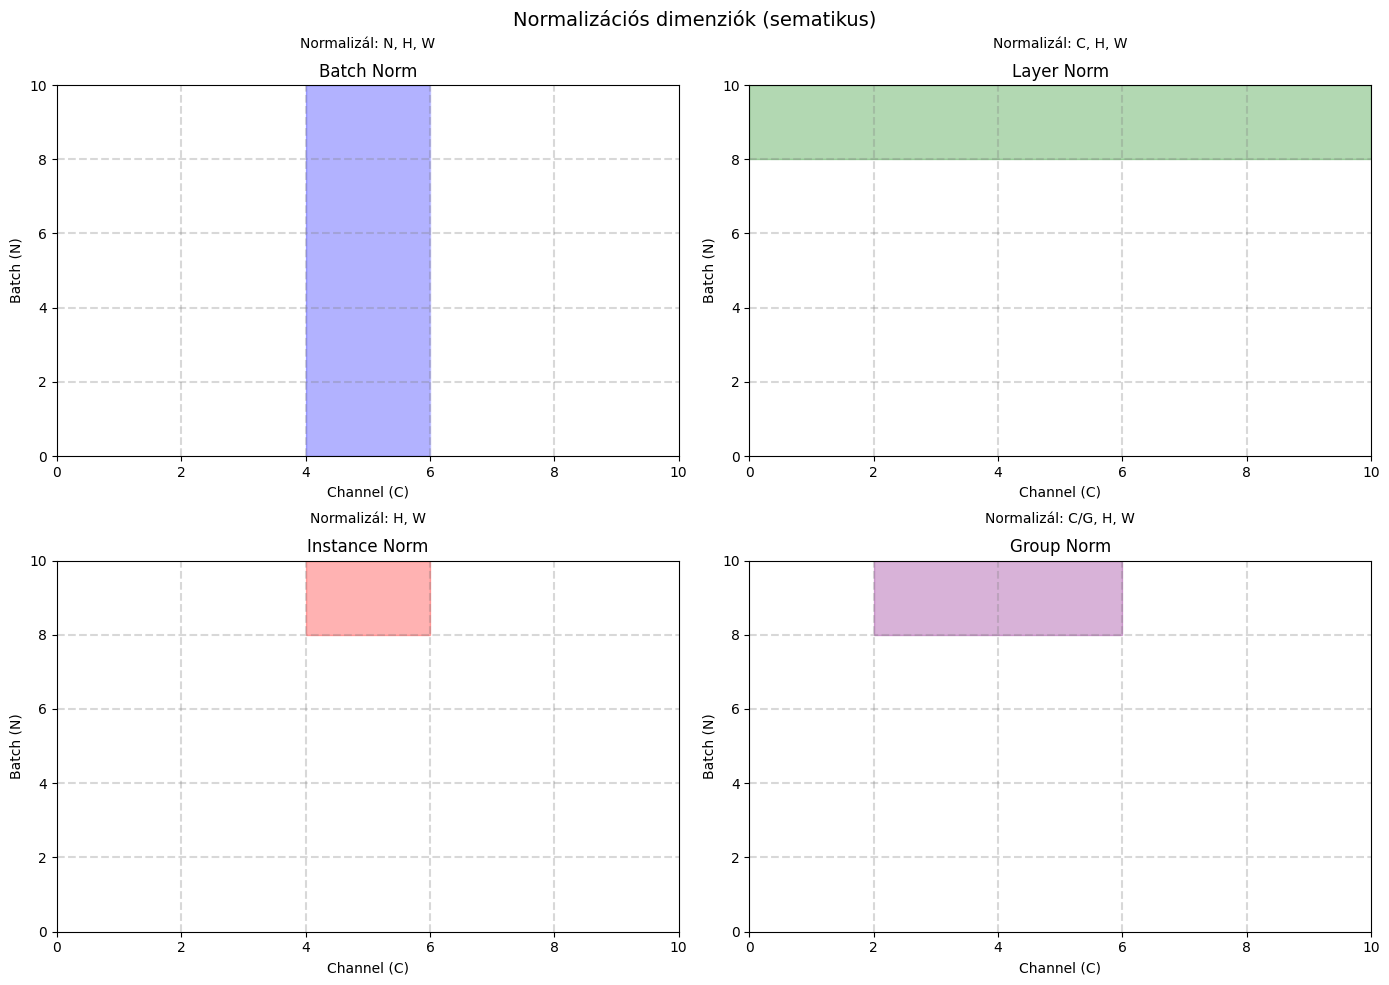

In [9]:
# Normalizálás vizualizáció

def visualize_norm_dims():
    """Normalizálási dimenziók vizualizálása."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Sematikus ábrázolás
    names = ['Batch Norm', 'Layer Norm', 'Instance Norm', 'Group Norm']
    colors = ['blue', 'green', 'red', 'purple']

    for ax, name, color in zip(axes.ravel(), names, colors):
        # N x C x H x W szimulálás
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)

        # Grid
        for i in range(1, 5):
            ax.axvline(i * 2, color='gray', linestyle='--', alpha=0.3)
            ax.axhline(i * 2, color='gray', linestyle='--', alpha=0.3)

        # Szín a normalizált dimenzióknál
        if name == 'Batch Norm':
            # C mentén (függőleges oszlop minden batch-ben)
            for col in range(5):
                rect = plt.Rectangle((col*2, 0), 2, 10, alpha=0.3, color=color if col == 2 else 'white', edgecolor='black')
                ax.add_patch(rect)
            ax.text(5, 11, 'Normalizál: N, H, W', ha='center')
        elif name == 'Layer Norm':
            # Minden feature egy mintán
            rect = plt.Rectangle((0, 8), 10, 2, alpha=0.3, color=color, edgecolor='black')
            ax.add_patch(rect)
            ax.text(5, 11, 'Normalizál: C, H, W', ha='center')
        elif name == 'Instance Norm':
            # Egy csatorna egy mintán
            rect = plt.Rectangle((4, 8), 2, 2, alpha=0.3, color=color, edgecolor='black')
            ax.add_patch(rect)
            ax.text(5, 11, 'Normalizál: H, W', ha='center')
        else:  # Group Norm
            # Csatornák csoportja
            rect = plt.Rectangle((2, 8), 4, 2, alpha=0.3, color=color, edgecolor='black')
            ax.add_patch(rect)
            ax.text(5, 11, 'Normalizál: C/G, H, W', ha='center')

        ax.set_xlabel('Channel (C)')
        ax.set_ylabel('Batch (N)')
        ax.set_title(name)

    plt.suptitle('Normalizációs dimenziók (sematikus)', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_norm_dims()

## 5. PyTorch implementáció

### BatchNorm hálózatban

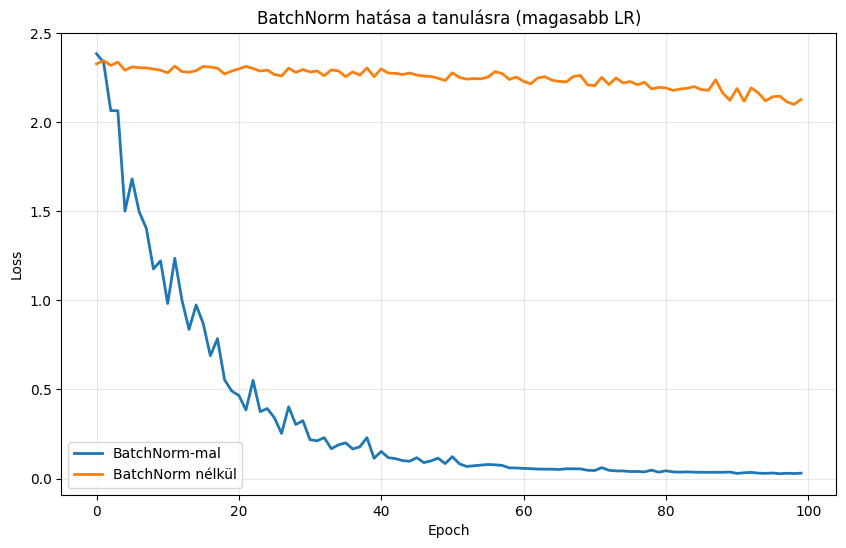

In [15]:
# CNN BatchNorm-mal

class CNNWithBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class CNNWithoutBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# MNIST-szerű adat generálás
X_train = torch.randn(500, 1, 28, 28)
y_train = torch.randint(0, 10, (500,))

def train_model(model, epochs=20, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    losses = []

    for epoch in range(epochs):
        # Mini-batch
        idx = torch.randperm(len(X_train))[:64]
        x_batch = X_train[idx]
        y_batch = y_train[idx]

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

# Összehasonlítás
torch.manual_seed(42)
model_bn = CNNWithBatchNorm()
losses_bn = train_model(model_bn, epochs=100, lr=0.1)

torch.manual_seed(42)
model_no_bn = CNNWithoutBatchNorm()
losses_no_bn = train_model(model_no_bn, epochs=100, lr=0.1)

plt.figure(figsize=(10, 6))
plt.plot(losses_bn, label='BatchNorm-mal', linewidth=2)
plt.plot(losses_no_bn, label='BatchNorm nélkül', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BatchNorm hatása a tanulásra (magasabb LR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# LayerNorm Transformer-hez

class TransformerBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.ReLU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        # Pre-norm architecture
        attn_out, _ = self.attention(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + attn_out

        x = x + self.ff(self.norm2(x))
        return x

# Teszt
block = TransformerBlock()
x = torch.randn(4, 10, 64)  # batch=4, seq_len=10, d_model=64
out = block(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Output mean: {out.mean().item():.4f}, std: {out.std().item():.4f}")

Input shape: torch.Size([4, 10, 64])
Output shape: torch.Size([4, 10, 64])
Output mean: -0.0036, std: 1.0293


## Összefoglalás

### Batch Normalization

| Lépés | Képlet |
|-------|--------|
| 1. Mean | $\mu_B = \frac{1}{m}\sum x_i$ |
| 2. Variance | $\sigma_B^2 = \frac{1}{m}\sum (x_i - \mu_B)^2$ |
| 3. Normalize | $\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$ |
| 4. Scale/Shift | $y = \gamma\hat{x} + \beta$ |

### Normalizációs módszerek

| Módszer | Használat | PyTorch |
|---------|----------|--------|
| BatchNorm | CNN | `nn.BatchNorm2d` |
| LayerNorm | Transformer | `nn.LayerNorm` |
| GroupNorm | Kis batch | `nn.GroupNorm` |

### Fontos

```python
model.train()  # Training mode
model.eval()   # Inference mode
```